# Cuaderno de limpieza de Pedro Herrero Bas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('dataset_final.csv')
df

,año,com_aut,pib,pob,sui,nat,paro,ing,homi,pib_pc,...,retrasos_pagos(%),renta_media,renta_mediana,riesgo_pobreza(%),dificultad_fin_mes(%),desigualdad_ing(S80/S20),inc_gastos_imprevistos(%),tasa_criminalidad,precio_medio_anual_eur_m2_venta,precio_medio_anual_eur_m2_alquiler
0,2009,Andalucía,145802256.0,8244.5,10.87,11.48,17.73,9437.0,0.94,17685.0,...,10.6,143930.0,126950.0,27.7,71.8,6.0,45.7,49.3,1757.50,7.27
1,2010,Andalucía,145853901.0,8302.9,9.89,11.10,25.24,9882.0,0.94,17567.0,...,12.9,141520.0,120860.0,28.1,73.9,6.2,52.2,49.3,1713.33,6.85
2,2011,Andalucía,144494494.0,8352.8,8.84,10.72,27.77,9793.0,1.02,17299.0,...,13.8,13310.0,113690.0,34.5,70.5,7.3,49.6,48.7,1723.42,6.72
3,2012,Andalucía,139052618.0,8378.3,8.30,10.30,30.13,9241.0,0.81,16597.0,...,15.5,133910.0,111170.0,35.6,71.6,6.2,51.4,47.1,1579.42,6.43
4,2013,Andalucía,137294091.0,8381.3,9.78,9.71,34.35,9361.0,0.78,16381.0,...,13.4,127050.0,108660.0,40.1,75.4,6.6,55.5,44.6,1443.42,6.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2018,Rioja,8649852.0,314.9,7.62,7.45,12.00,12561.0,0.32,27470.0,...,7.9,17490.0,15410.0,19.1,37.8,5.7,30.3,26.3,1180.17,5.89
262,2019,Rioja,8889997.0,317.0,6.11,7.66,10.40,12589.0,0.00,28040.0,...,4.9,186610.0,165770.0,17.5,25.4,5.0,19.0,27.6,1205.67,6.21
263,2020,Rioja,8186915.0,319.1,8.75,7.33,9.96,13371.0,1.57,25654.0,...,8.2,196980.0,175890.0,16.9,27.7,4.7,24.5,24.5,1215.08,6.58
264,2021,Rioja,8735750.0,319.2,8.27,6.94,10.80,14303.0,0.94,27365.0,...,8.0,187580.0,17420.0,16.8,32.3,5.1,22.5,28.6,1238.25,6.83


In [ ]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [ ]:
df_com = filtrar_columna(df, 'com_aut')

In [ ]:
df_com[0].index[0]

'Andalucía'

In [ ]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}
len(corr_matrices)

19

In [ ]:
def corr_to_vector(corr_df):
    '''Convierte una matriz de correlación en un vector de una dimensión con todos los valores cruzados.'''
    return (corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack())

# DataFrame: filas = datasets, columnas = pares de variables
corr_vectors = pd.DataFrame([corr_to_vector(matriz) for matriz in corr_matrices.values()])

corr_vectors.index = [key for key in corr_matrices.keys()]
corr_vectors

año                                          \
                           pib       pob       sui       nat      paro   
Andalucía             0.796477  0.920106 -0.469589 -0.992357 -0.253891   
Aragón                0.805034 -0.542157  0.326137 -0.986057 -0.271785   
Asturias              0.554838 -0.990202  0.173727 -0.981548 -0.107164   
Balears               0.739768  0.978995 -0.657127 -0.982874 -0.408335   
Canarias              0.614250  0.981257  0.236305 -0.980841 -0.299342   
Cantabria             0.742284 -0.614909  0.537352 -0.996174 -0.116096   
Castilla - La Mancha  0.723787 -0.684320 -0.027022 -0.991296 -0.168516   
Castilla Y León       0.715210 -0.986964  0.442991 -0.990941 -0.278922   
Cataluña              0.849957  0.812548  0.652973 -0.991957 -0.379584   
Ceuta                 0.809736  0.544966 -0.163201 -0.954624  0.261615   
Comunitat Valenciana  0.803639  0.548128  0.169689 -0.991228 -0.372363   
Extremadura           0.825785 -0.961539  0.127759 -0.981116 -0.002972   
Galicia               0.817789 -0.956176 -0.113362 -0.981640 -0.148337   
Madrid                0.879551  0.902504  0.767841 -0.991715 -0.250544   
Melilla               0.870554  0.824839 -0.484784 -0.835753  0.314254   
Murcia                0.856204  0.924859  0.218028 -0.991297 -0.385479   
Navarra               0.837942  0.922289 -0.366774 -0.985858 -0.176684   
País Vasco            0.823202  0.775522 -0.216717 -0.980627 -0.117329   
Rioja                 0.781367 -0.153452 -0.153608 -0.988903 -0.288915   

                                                                        ...  \
                           ing      homi    pib_pc  renta_pc poblacion  ...   
Andalucía             0.307417 -0.458932  0.756192  0.830452  0.843310  ...   
Aragón                0.657572 -0.235263  0.835382  0.836420 -0.732143  ...   
Asturias              0.382205 -0.711821  0.734362  0.863784 -0.994330  ...   
Balears               0.484590 -0.422179  0.573612  0.767489  0.990889  ...   
Canarias              0.515176 -0.073211  0.385808  0.796492  0.980783  ...   
Cantabria             0.459939  0.132531  0.769608  0.843329 -0.811445  ...   
Castilla - La Mancha  0.336975  0.193652  0.776590  0.873895 -0.483599  ...   
Castilla Y León       0.780713       NaN  0.842237  0.878670 -0.993971  ...   
Cataluña              0.706280 -0.660504  0.817869  0.827202  0.931381  ...   
Ceuta                 0.562374  0.223980  0.577608  0.681798  0.577390  ...   
Comunitat Valenciana  0.350546 -0.527011  0.799718  0.852402  0.965446  ...   
Extremadura           0.345423 -0.116104  0.856748  0.913446 -0.957544  ...   
Galicia               0.887528 -0.454683  0.855457  0.891046 -0.996784  ...   
Madrid                0.633040 -0.666939  0.843776  0.870661  0.978688  ...   
Melilla               0.176761 -0.072241  0.371131  0.627456  0.911776  ...   
Murcia                0.227853 -0.164388  0.819677  0.841843  0.998075  ...   
Navarra               0.370039  0.052865  0.784804  0.656848  0.937761  ...   
País Vasco            0.678866 -0.289594  0.808013  0.803000 -0.273248  ...   
Rioja                 0.811014  0.081684  0.808533  0.859671  0.708159  ...   

                      desigualdad_ing(S80/S20)                    \
                     inc_gastos_imprevistos(%) tasa_criminalidad   
Andalucía                             0.549892          0.064576   
Aragón                                0.494662         -0.279536   
Asturias                              0.264723         -0.153141   
Balears                               0.571938          0.368860   
Canarias                              0.426502         -0.355075   
Cantabria                             0.203692         -0.064663   
Castilla - La Mancha                  0.561137         -0.165974   
Castilla Y León                       0.547112          0.070070   
Cataluña                              0.533931         -0.263163   
Ceuta                                -0.451198          0.068765

In [ ]:
corr_summary = pd.DataFrame({'mean': corr_vectors.mean(), 'std': corr_vectors.std()})
corr_summary.head()

mean       std
año pib   0.781441  0.084470
    pob   0.170858  0.824301
    sui   0.052664  0.399022
    nat  -0.977727  0.035523
    paro -0.181599  0.198748

In [ ]:
def std_category(std):
    if std < 0.05:
        return "low"       # círculo
    elif std < 0.10:
        return "medium"    # cuadrado
    else:
        return "high"      # triángulo

corr_summary["std_cat"] = corr_summary["std"].apply(std_category)
corr_summary

mean  \
año                             pib                                 0.781441   
                                pob                                 0.170858   
                                sui                                 0.052664   
                                nat                                -0.977727   
                                paro                               -0.181599   
...                                                                      ...   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta    -0.118264   
                                precio_medio_anual_eur_m2_alquiler -0.330514   
tasa_criminalidad               precio_medio_anual_eur_m2_venta     0.164895   
                                precio_medio_anual_eur_m2_alquiler  0.137913   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.307177   

                                                                         std  \
año                             pib                                 0.084470   
                                pob                                 0.824301   
                                sui                                 0.399022   
                                nat                                 0.035523   
                                paro                                0.198748   
...                                                                      ...   
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta     0.448083   
                                precio_medio_anual_eur_m2_alquiler  0.390208   
tasa_criminalidad               precio_medio_anual_eur_m2_venta     0.410355   
                                precio_medio_anual_eur_m2_alquiler  0.425166   
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler  0.404925   

                                                                   std_cat  
año                             pib                                 medium  
                                pob                                   high  
                                sui                                   high  
                                nat                                    low  
                                paro                                  high  
...                                                                    ...  
inc_gastos_imprevistos(%)       precio_medio_anual_eur_m2_venta       high  
                                precio_medio_anual_eur_m2_alquiler    high  
tasa_criminalidad               precio_medio_anual_eur_m2_venta       high  
                                precio_medio_anual_eur_m2_alquiler    high  
precio_medio_anual_eur_m2_venta precio_medio_anual_eur_m2_alquiler    high  

[253 rows x 3 columns]

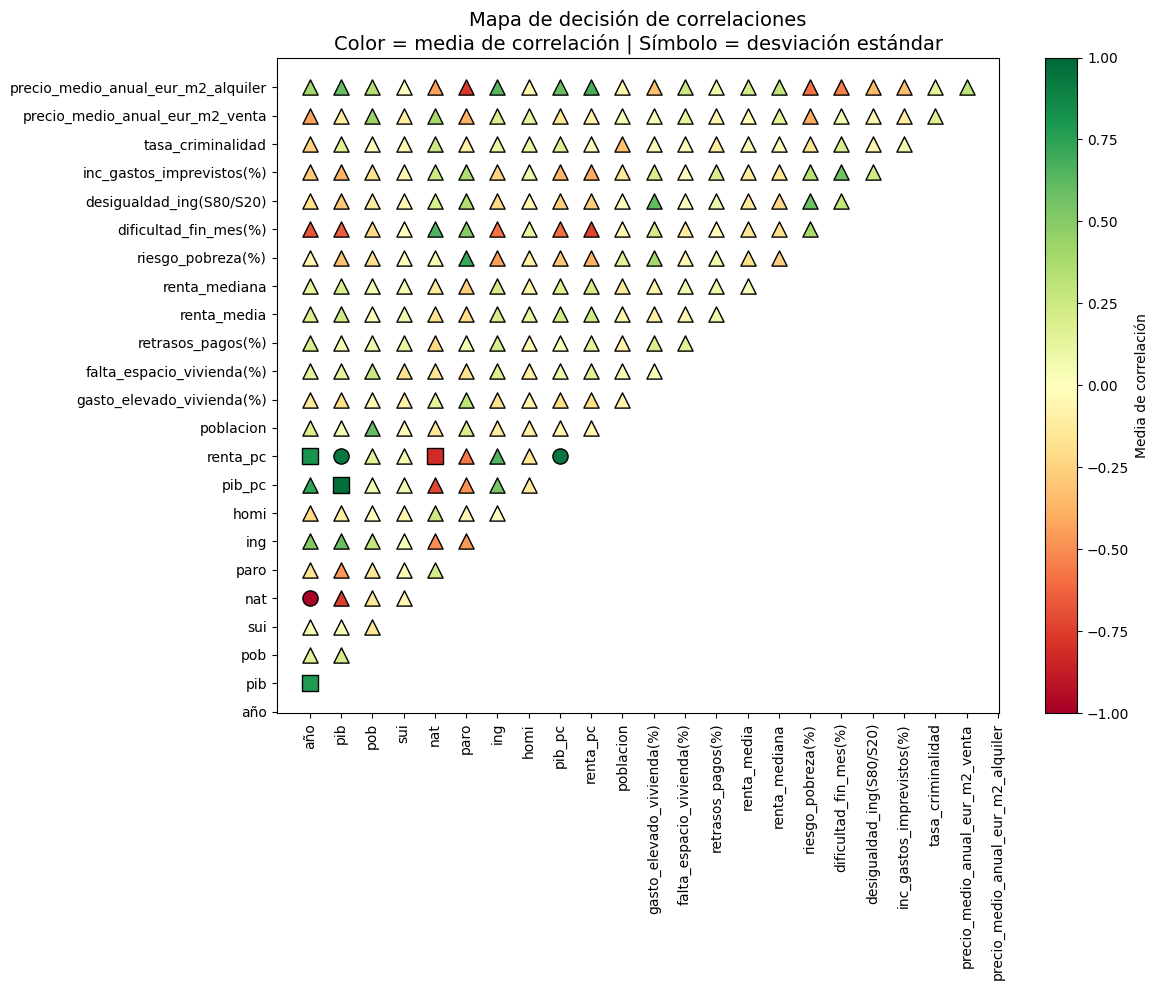

In [ ]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in corr_summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",     # círculo
        "medium": "s",  # cuadrado
        "high": "^"     # triángulo
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black"
    )

# Ejes
ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media de correlación | Símbolo = desviación estándar",
    fontsize=14
)

# Barra de color
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


🔹 PALANCA 1 — Fisher Z-transform (CLAVE)

Promediar correlaciones en r es mala idea.

Solución:

Transformar primero:

r → z

promediar

volver a r

🔹 Qué hace Fisher Z

Transforma:

𝑧
=
tanh
⁡
−
1
(
𝑟
)
z=tanh
−1
(r)

Propiedades clave:

Distribución aproximadamente normal

Varianza independiente del valor de r

Pensado EXACTAMENTE para:

comparar

promediar

hacer meta-análisis

Después:

𝑟
=
tanh
⁡
(
𝑧
)
r=tanh(z)

👉 No cambia la correlación, cambia cómo la agregas.

🔹 Cuándo usar Fisher Z

✔️ Siempre que:

Promedias correlaciones

Comparas correlaciones entre muestras

Quieres estabilidad estadística

📌 En tu caso: obligatorio, no opcional.

In [ ]:
from numpy import arctanh, tanh

z_vectors = corr_vectors.apply(np.arctanh)
z_mean = z_vectors.mean()
z_std = z_vectors.std()

summary = pd.DataFrame({
    "mean": np.tanh(z_mean),
    "std": z_std
})

🔹 PALANCA 2 — Relajar el concepto de “estabilidad”

Ahora mismo estás siendo muy duro.

Ejemplo más realista:

In [ ]:
def std_category(std):
    if std < 0.10:
        return "low"
    elif std < 0.20:
        return "medium"
    else:
        return "high"


🔹 PALANCA 3 — Estabilidad de signo (muy potente)

Aunque el valor fluctúe, ¿el signo se mantiene?

In [ ]:
sign_consistency = (corr_vectors > 0).mean().abs()

🔹 PALANCA 4 — Filtrar por magnitud mínima

Muchas correlaciones son “ruido pequeño”.

In [ ]:
mask = corr_vectors.abs().mean() > 0.2
corr_vectors = corr_vectors.loc[:, mask]

4️⃣ Código COMPLETO aplicando 1–2–3–4

4.1 Fisher Z + estadísticas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fisher Z transform
z_vectors = corr_vectors.apply(np.arctanh)

summary = pd.DataFrame({
    "mean_r": np.tanh(z_vectors.mean()),   # media correcta
    "std_z": z_vectors.std(),               # variabilidad real
    "sign_consistency": (corr_vectors > 0).mean().abs()
})


4.2 Filtrar por magnitud (palanca 4)

In [ ]:
summary = summary[summary["mean_r"].abs() > 0.2]

4.3 Clasificar estabilidad (palanca 2)

In [ ]:
def std_category(std):
    if std < 0.20:
        return "low"
    elif std < 0.40:
        return "medium"
    else:
        return "high"

summary["std_cat"] = summary["std_z"].apply(std_category)


5️⃣ Código de la GRÁFICA (final)

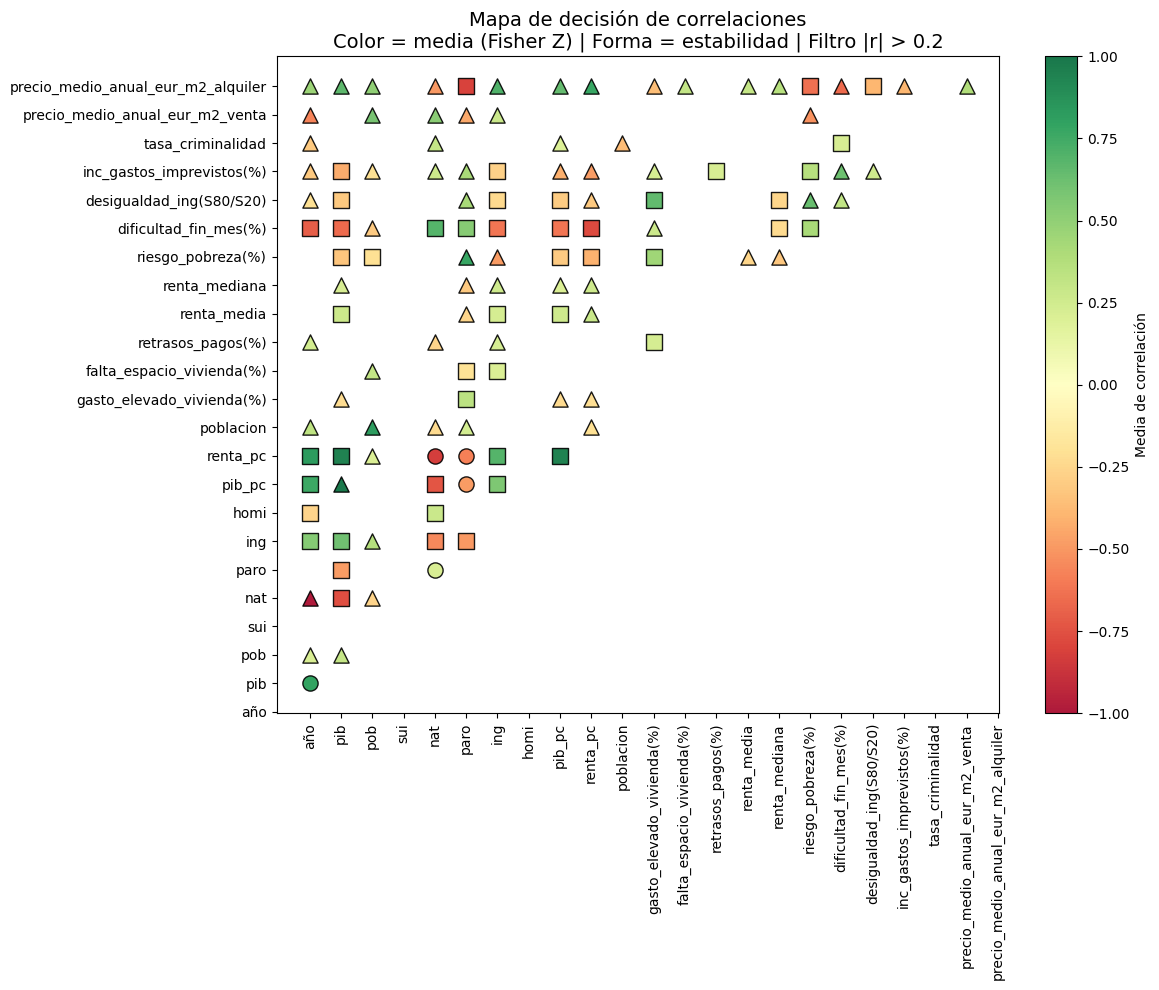

In [ ]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x, y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media (Fisher Z) | Forma = estabilidad | Filtro |r| > 0.2",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


In [ ]:
summary_sym = summary.copy()

# Intercambiar los pares (A, B) → (B, A)
summary_sym.index = pd.MultiIndex.from_tuples(
    [(j, i) for i, j in summary.index],
    names=summary.index.names
)

# Unir original + simétrica
summary_full = pd.concat([summary, summary_sym])


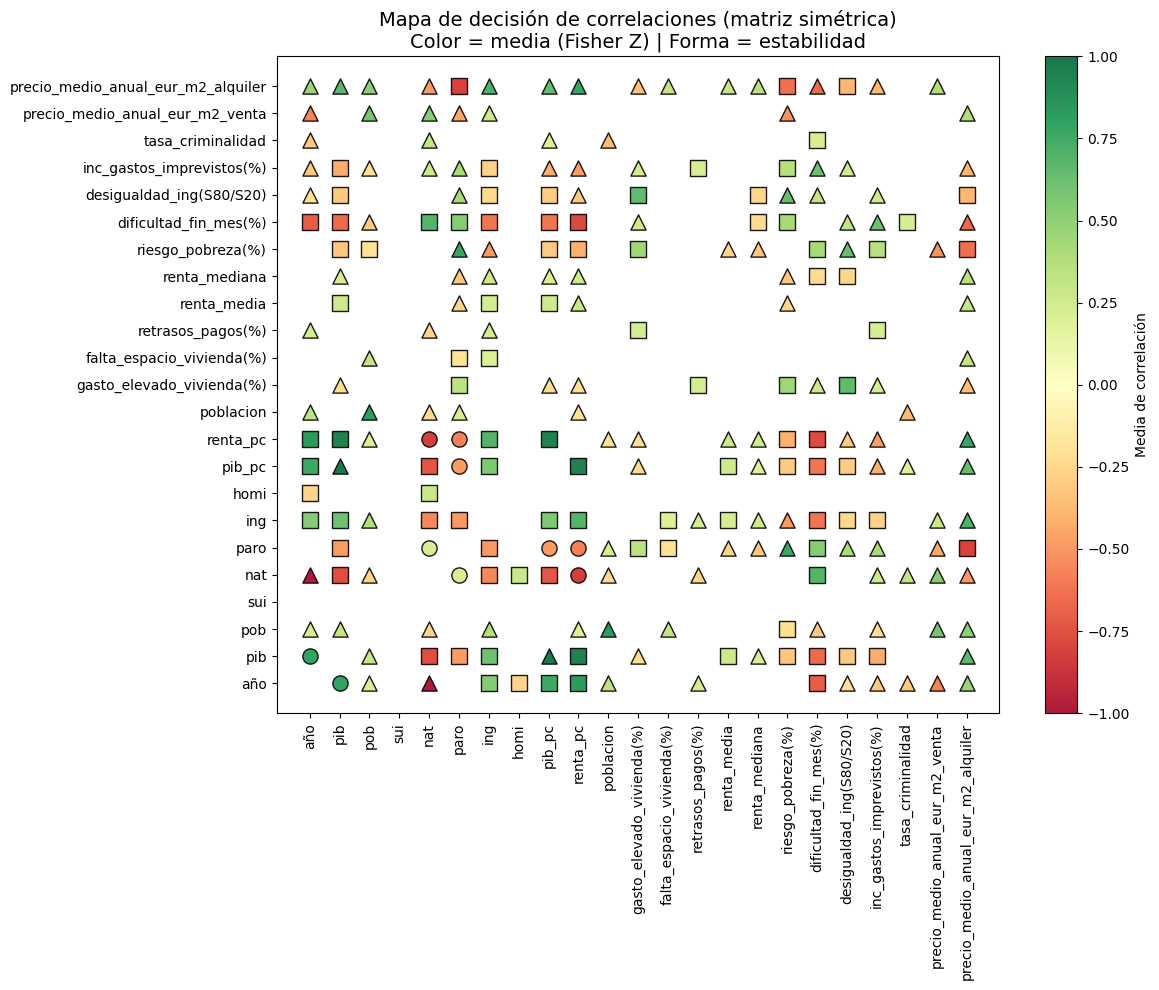

In [ ]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary_full.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones (matriz simétrica)\n"
    "Color = media (Fisher Z) | Forma = estabilidad",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


In [ ]:
df['pib'] / df['poblacion']

0      19.114731
1      19.023796
2      18.780282
3      18.052041
4      17.805947
         ...    
261    30.890343
262    31.799051
263    29.269925
264    31.321597
265    35.114670
Length: 266, dtype: float64